# Interactive plots

In [1]:
from functools import partial
from pathlib import Path
import tempfile
import tomllib
from numpy.typing import NDArray

from multipac_testbench import PowerStepSet
from multipac_testbench.data import config_path
from multipac_testbench.data.power_steps import power_step_set_example
from multipac_testbench.multipactor_test.helper import take_median
from multipac_testbench.instruments import CurrentProbe, FieldProbe, ForwardPower

with open(config_path, "rb") as f:
    config = tomllib.load(f)

power_step_set = PowerStepSet(
    power_step_set_example,
    config=config,
    freq_mhz=140.0,
    swr=1.0,
    is_raw=True,
    create_virtual_instruments=False,
)

In [2]:
def average(raw_data: NDArray) -> float:
    """Return average over last 100 points."""
    return take_median(raw_data, first_index=-100, last_index=-1)

def average_for_power(raw_data: NDArray) -> float:
    """Return average over last 40 points.
    
    Use it for Power signals, which are shifted wrt other signals.
    
    """
    return take_median(raw_data, first_index=-40, last_index=-1)


In [3]:
with tempfile.NamedTemporaryFile(suffix=".csv") as tmp:
    multipactor_test = power_step_set.to_multipactor_test(
        reducer=average,
        special_reducers={
            "NI9205_Power1": average_for_power,
            "NI9205_Power2": average_for_power
        },
        csv_path=Path(tmp.name),
    )

/home/placais/Documents/simulation/python/multipac_testbench/src/multipac_testbench/util/physics.py:28: RuntimeWarning: invalid value encountered in sqrt
  reflection_coefficient = np.abs(np.sqrt(reflected_power / forward_power))
ERROR:root:column_header = 'NI9205_E1' not present in provided file. Skipping associated instrument.


Clicking on somewhere on the graph should pick up the associated power step and plot it in a new figure. Currently does not work in notebooks.

In [4]:
%matplotlib widget

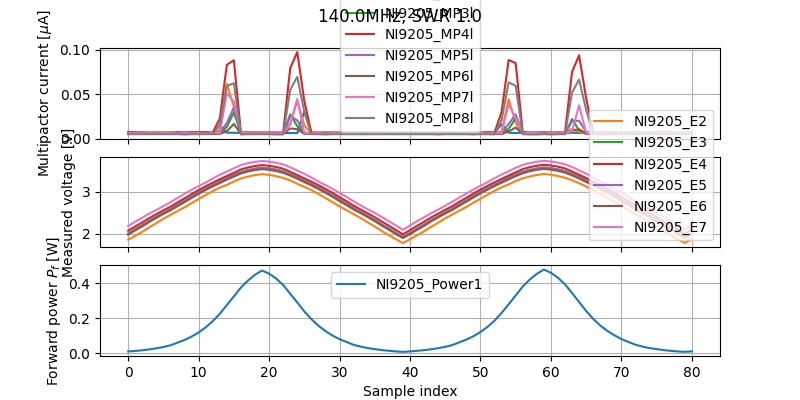

In [5]:
_ = multipactor_test.interactive_sweet_plot(CurrentProbe, FieldProbe, ForwardPower, figsize=(8, 4))